In [9]:
# ============================================================
# PART 1: IMPORT REQUIRED LIBRARIES
# ============================================================

import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from skimage.feature import local_binary_pattern

print("All required libraries imported successfully.")

All required libraries imported successfully.


In [10]:
# ============================================================
# PART 2: DEFINE DATASET PATHS AND LOAD ANNOTATIONS
# ============================================================

annotation_path = "kaggle_dataset/annotations.csv"
kaggle_image_folder = "kaggle_dataset/images"
test_image_root = "test_images"

# Check required paths
if not os.path.exists(annotation_path):
    raise FileNotFoundError(f"Annotation file not found: {annotation_path}")

if not os.path.exists(kaggle_image_folder):
    raise FileNotFoundError(f"Kaggle image folder not found: {kaggle_image_folder}")

if not os.path.exists(test_image_root):
    raise FileNotFoundError(f"Test image folder not found: {test_image_root}")

# Load annotation file
df = pd.read_csv(annotation_path)

print("Number of annotation rows:", len(df))
print("Number of unique images:", df["file_name"].nunique())
print("Number of categories:", df["category"].nunique())


Number of annotation rows: 6164
Number of unique images: 5998
Number of categories: 58


In [11]:
# ============================================================
# PART 3: SPATIAL LBP CONFIGURATION AND HELPER FUNCTIONS
# ============================================================

IMAGE_SIZE = (64, 64)
CELL_SIZE = 16

LBP_RADIUS = 1
LBP_POINTS = 8 * LBP_RADIUS
LBP_METHOD = "uniform"


def get_annotation(filename, image, annotations):

    height, width = image.shape[:2]

    rows = annotations[
        (annotations["file_name"] == filename) &
        (annotations["width"] == width) &
        (annotations["height"] == height)
    ]

    if len(rows) == 0:
        return None

    return rows.iloc[0]


def crop_annotated_roi(filename, image, annotations):

    annotation = get_annotation(filename, image, annotations)

    if annotation is None:
        return None, None

    height, width = image.shape[:2]

    x1 = max(0, int(annotation["x1"]))
    y1 = max(0, int(annotation["y1"]))
    x2 = min(width, int(annotation["x2"]))
    y2 = min(height, int(annotation["y2"]))

    if x2 <= x1 or y2 <= y1:
        return None, annotation

    roi = image[y1:y2, x1:x2]

    if roi.size == 0:
        return None, annotation

    return roi, annotation


def extract_lbp_features(roi):

    # Resize the traffic sign ROI
    resized = cv2.resize(
        roi,
        IMAGE_SIZE,
        interpolation=cv2.INTER_AREA
    )

    # Convert to grayscale
    gray = cv2.cvtColor(
        resized,
        cv2.COLOR_BGR2GRAY
    )

    # Apply Local Binary Pattern
    lbp_image = local_binary_pattern(
        gray,
        LBP_POINTS,
        LBP_RADIUS,
        method=LBP_METHOD
    )

    num_bins = LBP_POINTS + 2
    feature_vector = []

    # Divide the image into 4 x 4 cells
    for y_pos in range(0, IMAGE_SIZE[1], CELL_SIZE):
        for x_pos in range(0, IMAGE_SIZE[0], CELL_SIZE):

            cell = lbp_image[
                y_pos:y_pos + CELL_SIZE,
                x_pos:x_pos + CELL_SIZE
            ]

            hist, _ = np.histogram(
                cell.ravel(),
                bins=np.arange(0, num_bins + 1),
                range=(0, num_bins)
            )

            # Normalize the histogram
            hist = hist.astype(float)
            hist /= (hist.sum() + 1e-7)

            feature_vector.extend(hist)

    return np.asarray(feature_vector), gray, lbp_image


In [12]:
# ============================================================
# PART 4: EXCLUDE TEST IMAGES FROM KAGGLE FEATURE POOL
# ============================================================

# Collect test filenames only
test_filenames_to_exclude = {
    filename
    for root, dirs, files in os.walk(test_image_root)
    for filename in files
    if filename.lower().endswith(
        (".png", ".jpg", ".jpeg", ".bmp")
    )
}

# Collect all Kaggle image filenames
all_kaggle_files = sorted([
    filename
    for filename in os.listdir(kaggle_image_folder)
    if filename.lower().endswith(
        (".png", ".jpg", ".jpeg", ".bmp")
    )
])

# Remove test images from the Kaggle feature pool
kaggle_feature_files = [
    filename
    for filename in all_kaggle_files
    if filename not in test_filenames_to_exclude
]

print("Total Kaggle images:", len(all_kaggle_files))
print("Reserved test image filenames:", len(test_filenames_to_exclude))
print(
    "Images removed from Kaggle feature pool:",
    len(all_kaggle_files) - len(kaggle_feature_files)
)
print(
    "Remaining Kaggle images:",
    len(kaggle_feature_files)
)


Total Kaggle images: 5998
Reserved test image filenames: 84
Images removed from Kaggle feature pool: 84
Remaining Kaggle images: 5914


In [13]:
# ============================================================
# PART 5: EXTRACT KAGGLE SPATIAL LBP FEATURES
# ============================================================

feature_list = []
label_list = []

examples = []
example_classes = set()

failed_images = []

print("=" * 65)
print("TASK 1: SPATIAL LBP FEATURE EXTRACTION")
print("=" * 65)
print("Extracting LBP features...")

for filename in kaggle_feature_files:

    image_path = os.path.join(
        kaggle_image_folder,
        filename
    )

    image = cv2.imread(image_path)

    if image is None:
        failed_images.append(filename)
        continue

    # Crop traffic sign ROI
    cropped_sign, annotation = crop_annotated_roi(
        filename,
        image,
        df
    )

    if cropped_sign is None or annotation is None:
        failed_images.append(filename)
        continue

    category = int(annotation["category"])

    # Extract LBP feature vector
    features, gray, lbp_image = extract_lbp_features(
        cropped_sign
    )

    feature_list.append(features)
    label_list.append(category)

    # Select 10 examples from different classes
    if (
        len(examples) < 10
        and category not in example_classes
    ):
        examples.append(
            (
                image,
                cropped_sign,
                gray,
                lbp_image,
                filename,
                category
            )
        )

        example_classes.add(category)

# Complete LBP feature matrix
X_lbp = np.vstack(feature_list)
y_lbp = np.asarray(label_list)

print("\nLBP extraction completed.")
print(f"Images successfully processed : {len(X_lbp)}")
print(f"Failed images                  : {len(failed_images)}")
print(f"LBP features per image         : {X_lbp.shape[1]}")
print(f"LBP feature matrix shape       : {X_lbp.shape}")
print(f"Label array shape              : {y_lbp.shape}")
print(f"Visualisation examples         : {len(examples)}")


TASK 1: SPATIAL LBP FEATURE EXTRACTION
Extracting LBP features...

LBP extraction completed.
Images successfully processed : 5914
Failed images                  : 0
LBP features per image         : 160
LBP feature matrix shape       : (5914, 160)
Label array shape              : (5914,)
Visualisation examples         : 10


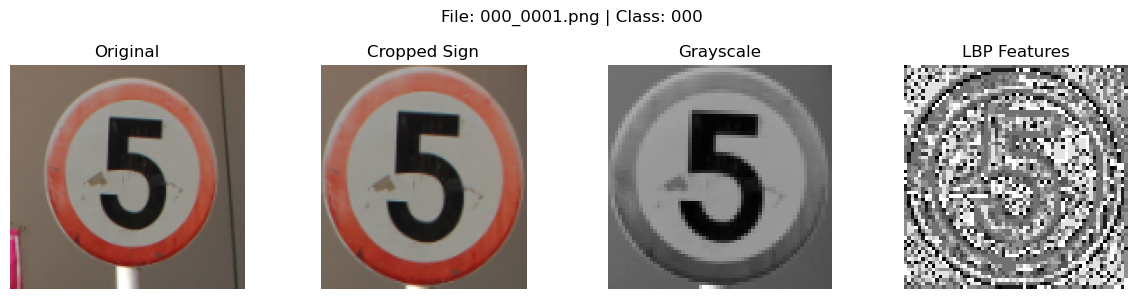

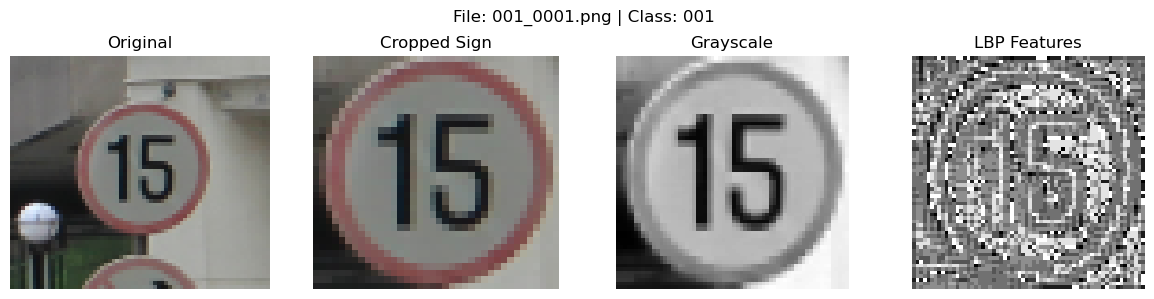

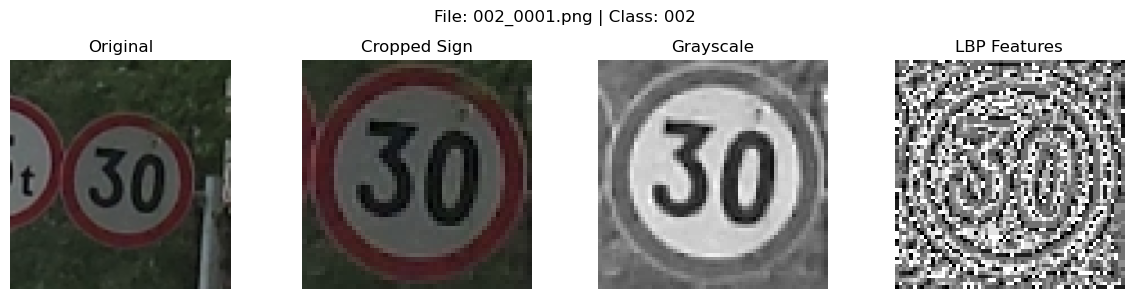

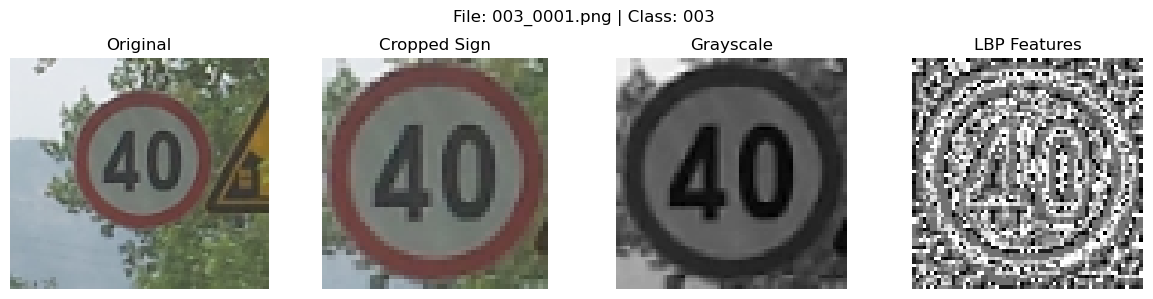

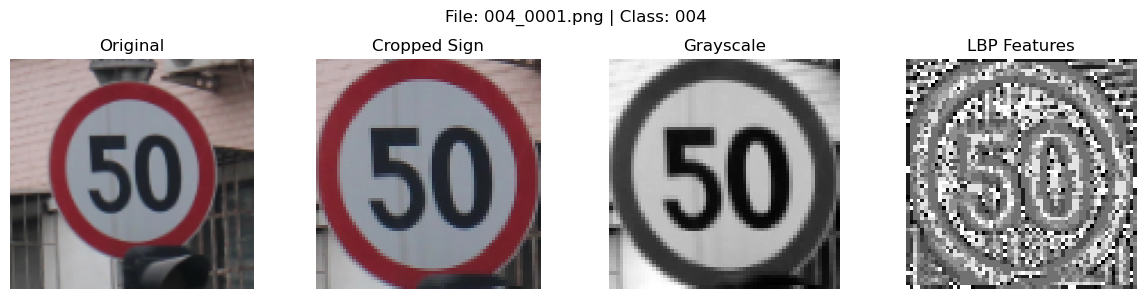

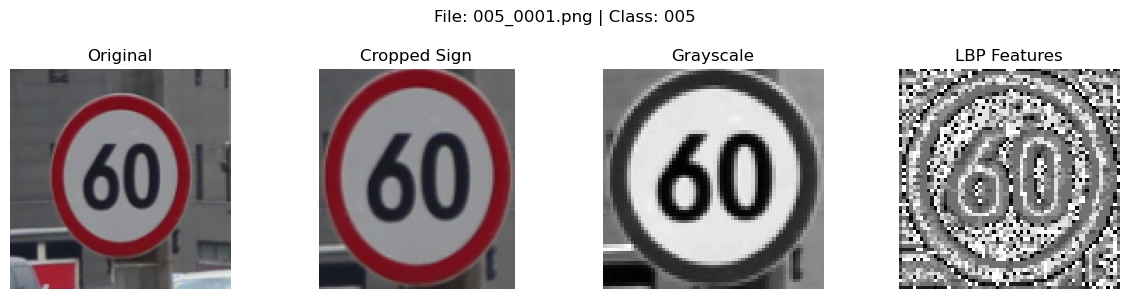

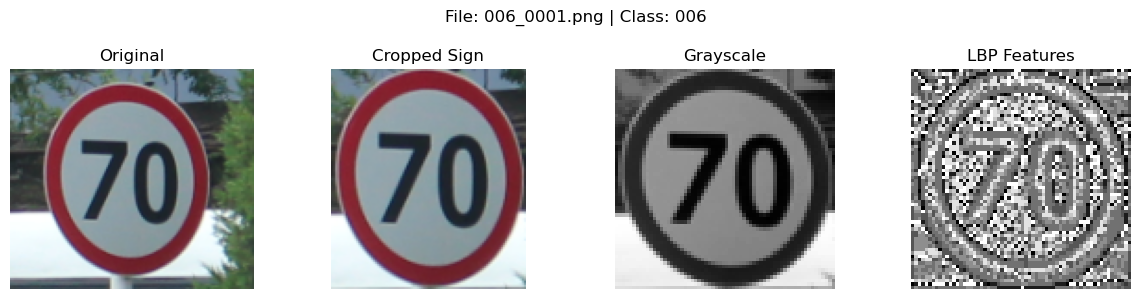

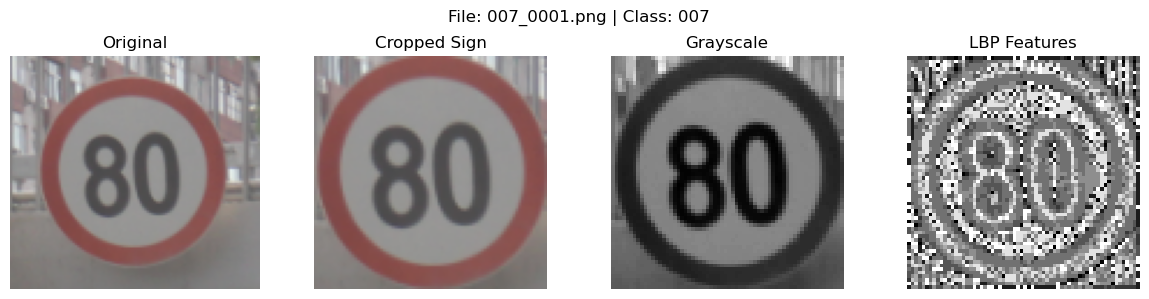

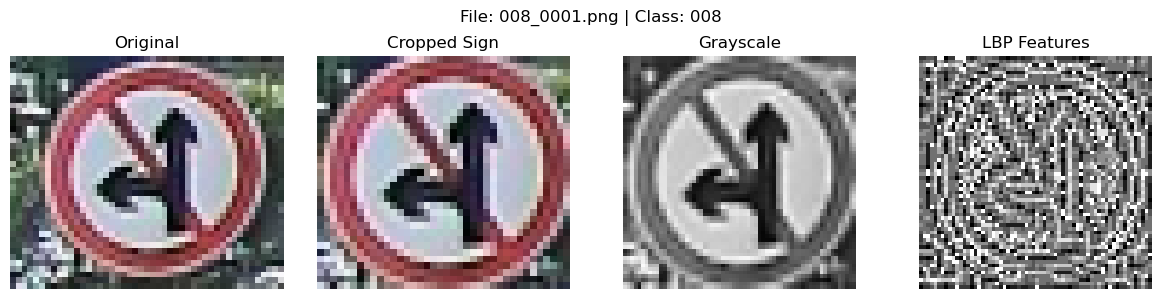

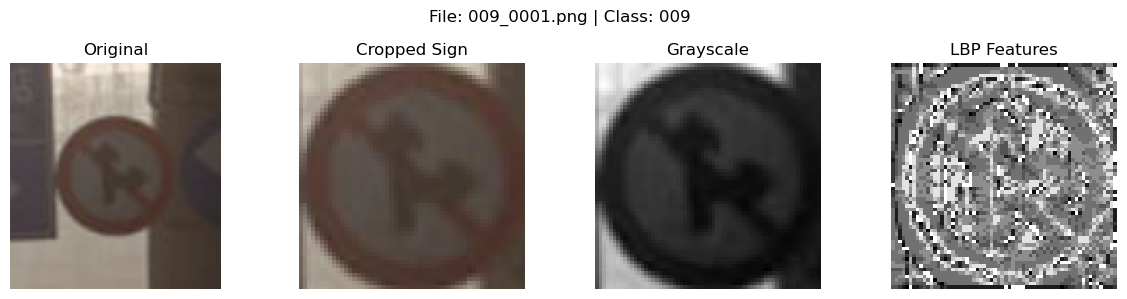

In [14]:
# ============================================================
# PART 6: DISPLAY 10 KAGGLE LBP EXAMPLES
# ============================================================

for (
    image,
    cropped_sign,
    gray,
    lbp_image,
    filename,
    category
) in examples:

    original_rgb = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    cropped_rgb = cv2.cvtColor(
        cropped_sign,
        cv2.COLOR_BGR2RGB
    )

    fig, axes = plt.subplots(
        1,
        4,
        figsize=(12, 3)
    )

    axes[0].imshow(original_rgb)
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(cropped_rgb)
    axes[1].set_title("Cropped Sign")
    axes[1].axis("off")

    axes[2].imshow(
        gray,
        cmap="gray"
    )
    axes[2].set_title("Grayscale")
    axes[2].axis("off")

    axes[3].imshow(
        lbp_image,
        cmap="gray"
    )
    axes[3].set_title("LBP Features")
    axes[3].axis("off")

    fig.suptitle(
        f"File: {filename} | Class: {category:03d}"
    )

    plt.tight_layout()
    plt.show()


In [15]:
# ============================================================
# PART 7: EXTRACT SPATIAL LBP FEATURES FROM TEST IMAGES
# ============================================================

test_image_paths = sorted([
    os.path.join(root, filename)
    for root, dirs, files in os.walk(test_image_root)
    for filename in files
    if filename.lower().endswith(
        (".png", ".jpg", ".jpeg", ".bmp")
    )
])

test_feature_list = []
test_label_list = []

test_examples = []
test_example_classes = set()

failed_test_images = []

for image_path in test_image_paths:

    filename = os.path.basename(image_path)
    image = cv2.imread(image_path)

    if image is None:
        failed_test_images.append(filename)
        continue

    # Crop traffic sign ROI
    cropped_sign, annotation = crop_annotated_roi(
        filename,
        image,
        df
    )

    if cropped_sign is None or annotation is None:
        failed_test_images.append(filename)
        continue

    category = int(annotation["category"])

    # Extract the same LBP feature vector
    features, gray, lbp_image = extract_lbp_features(
        cropped_sign
    )

    test_feature_list.append(features)
    test_label_list.append(category)

    # Select 10 examples from different classes
    if (
        len(test_examples) < 10
        and category not in test_example_classes
    ):
        test_examples.append(
            (
                image,
                cropped_sign,
                gray,
                lbp_image,
                filename,
                category
            )
        )

        test_example_classes.add(category)

# Complete test feature matrix
X_test_lbp = np.vstack(test_feature_list)
y_test_lbp = np.asarray(test_label_list)

print("=" * 65)
print("TEST IMAGE LBP FEATURE EXTRACTION")
print("=" * 65)

print(f"Images successfully processed : {len(X_test_lbp)}")
print(f"Failed images                  : {len(failed_test_images)}")
print(f"LBP features per image         : {X_test_lbp.shape[1]}")
print(f"LBP feature matrix shape       : {X_test_lbp.shape}")
print(f"Label array shape              : {y_test_lbp.shape}")
print(f"Visualisation examples         : {len(test_examples)}")


TEST IMAGE LBP FEATURE EXTRACTION
Images successfully processed : 84
Failed images                  : 0
LBP features per image         : 160
LBP feature matrix shape       : (84, 160)
Label array shape              : (84,)
Visualisation examples         : 10


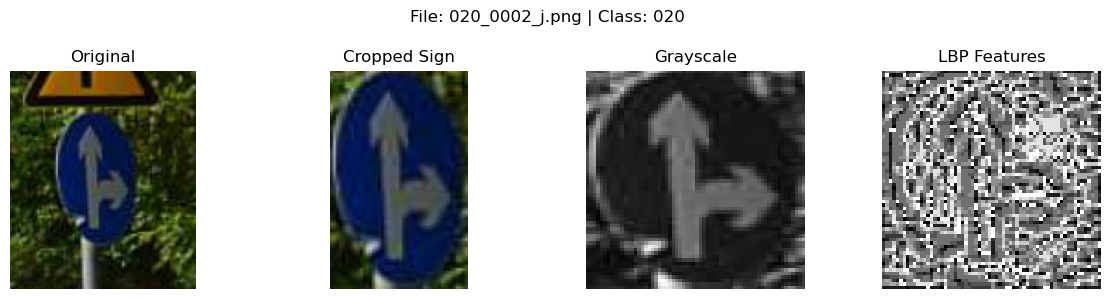

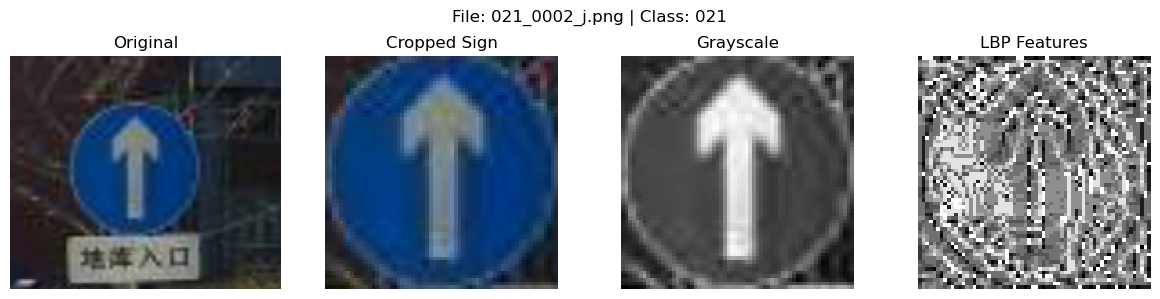

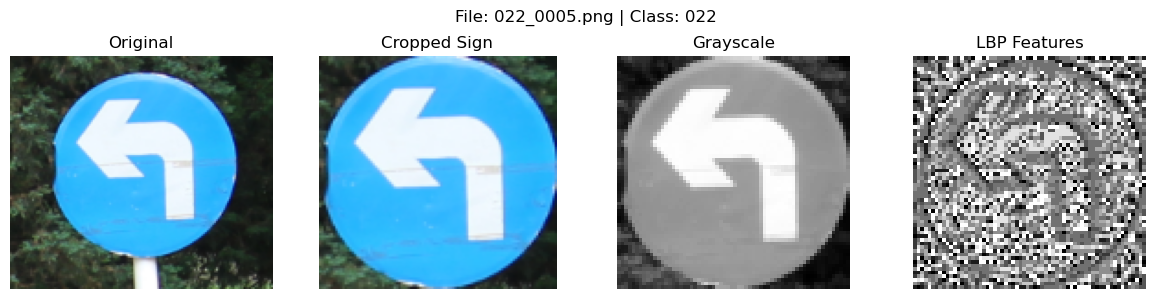

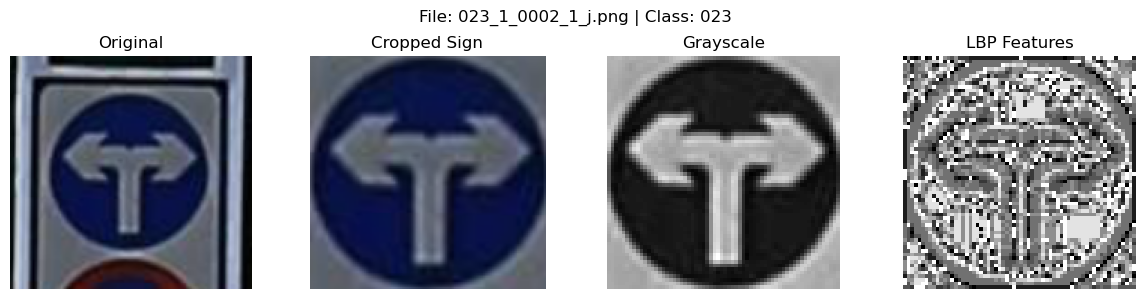

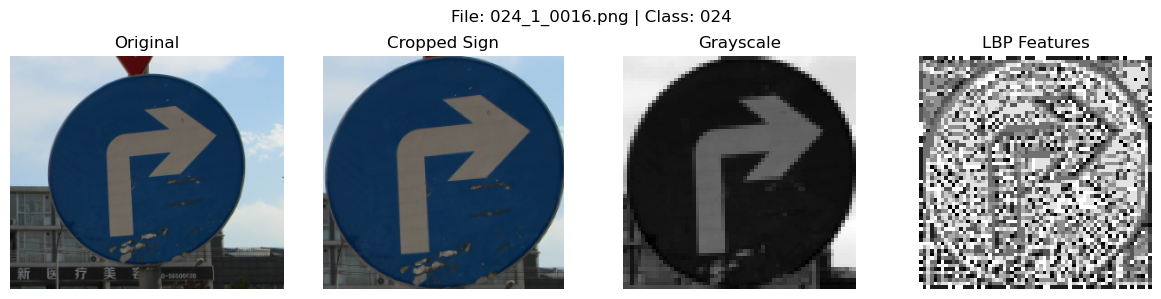

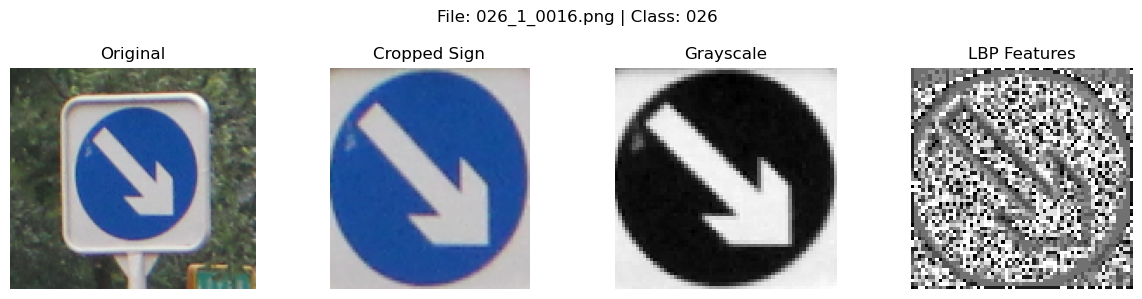

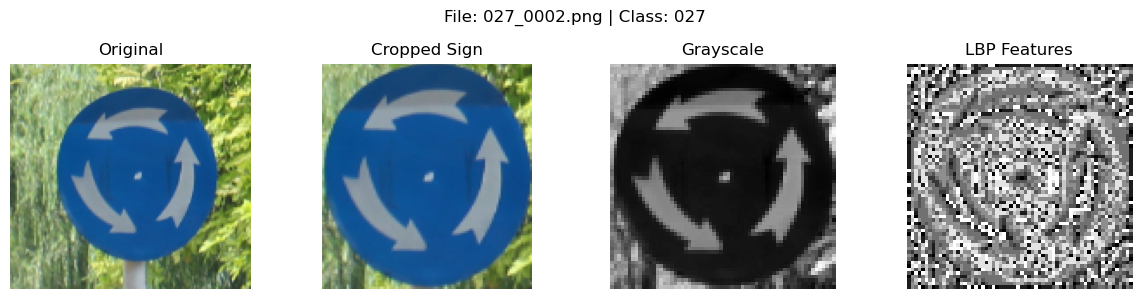

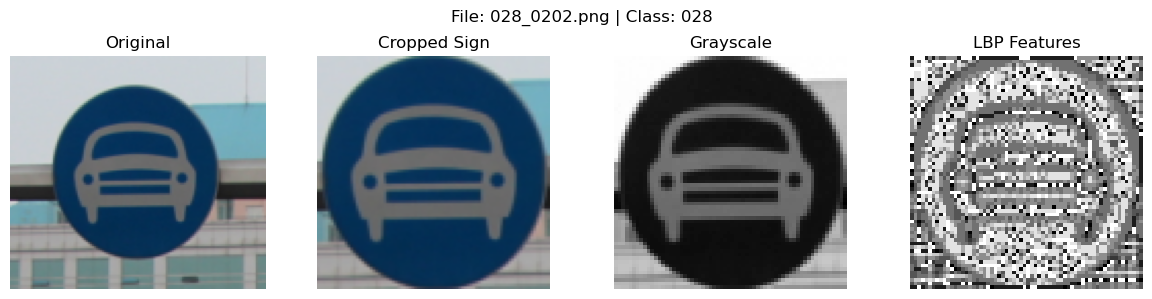

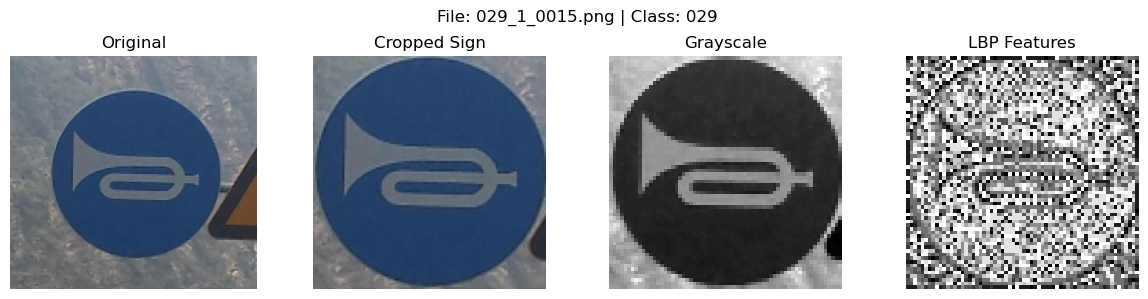

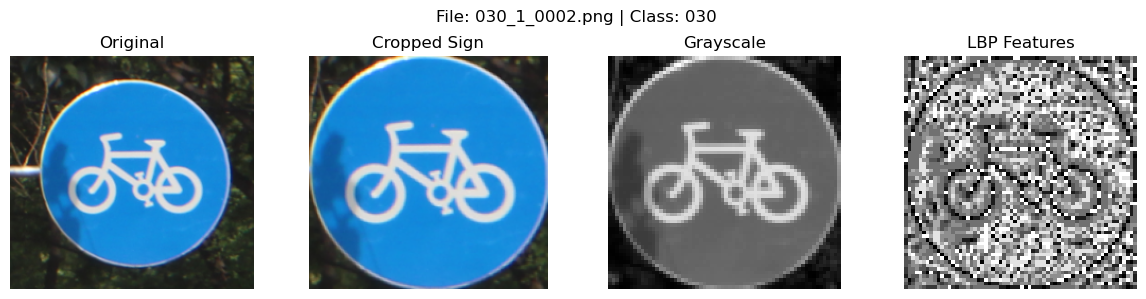

In [16]:
# ============================================================
# PART 8: DISPLAY 10 TEST IMAGE LBP EXAMPLES
# ============================================================

for (
    image,
    cropped_sign,
    gray,
    lbp_image,
    filename,
    category
) in test_examples:

    original_rgb = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    cropped_rgb = cv2.cvtColor(
        cropped_sign,
        cv2.COLOR_BGR2RGB
    )

    fig, axes = plt.subplots(
        1,
        4,
        figsize=(12, 3)
    )

    axes[0].imshow(original_rgb)
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(cropped_rgb)
    axes[1].set_title("Cropped Sign")
    axes[1].axis("off")

    axes[2].imshow(
        gray,
        cmap="gray"
    )
    axes[2].set_title("Grayscale")
    axes[2].axis("off")

    axes[3].imshow(
        lbp_image,
        cmap="gray"
    )
    axes[3].set_title("LBP Features")
    axes[3].axis("off")

    fig.suptitle(
        f"File: {filename} | Class: {category:03d}"
    )

    plt.tight_layout()
    plt.show()
